# CardioIA — ECG heartbeat classification (Keras MLP)

The Kaggle dataset contains **ECG signals, not images**: each row is one heartbeat with 187 values + 1 label.
Two MLP models are trained:

| Model | Data | Task | Output |
|---|---|---|---|
| A | PTB Diagnostic ECG | normal × abnormal | `Dense(1, sigmoid)` |
| B | MIT-BIH Arrhythmia | 5 heartbeat types (N, S, V, F, Q) | `Dense(5, softmax)` |

Academic project — not for clinical use.

## 1. Imports

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
keras.utils.set_random_seed(SEED)
tf.get_logger().setLevel("ERROR")

FREQ_HZ = 125
N_SAMPLES = 187
TIME = np.arange(N_SAMPLES) / FREQ_HZ

PTB_NAMES = ["Normal", "Abnormal"]
MIT_NAMES = ["N - Normal", "S - Supraventricular", "V - Ventricular", "F - Fusion", "Q - Unknown"]

## 2. Loading the ECG data

Download first with `uv run python src/data_collection/download_ecg.py` (files go to `data/raw/ecg/`).

In [2]:
FILES = ["mitbih_train.csv", "mitbih_test.csv", "ptbdb_normal.csv", "ptbdb_abnormal.csv"]

def find_data():
    for folder in [Path("../data/raw/ecg"), Path("data/raw/ecg")]:
        if all((folder / f).exists() for f in FILES):
            return folder
    import kagglehub
    return Path(kagglehub.dataset_download("shayanfazeli/heartbeat"))

DATA_DIR = find_data()
RESULTS_DIR = Path("../results/ecg") if Path("../src").exists() else Path("results/ecg")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

ptb_normal = pd.read_csv(DATA_DIR / "ptbdb_normal.csv", header=None)
ptb_abnormal = pd.read_csv(DATA_DIR / "ptbdb_abnormal.csv", header=None)
mit_train = pd.read_csv(DATA_DIR / "mitbih_train.csv", header=None)
mit_test = pd.read_csv(DATA_DIR / "mitbih_test.csv", header=None)

for name, df in [("ptbdb_normal", ptb_normal), ("ptbdb_abnormal", ptb_abnormal),
                 ("mitbih_train", mit_train), ("mitbih_test", mit_test)]:
    print(f"{name:<15} {df.shape[0]:>6} rows x {df.shape[1]} columns")

ptbdb_normal      4046 rows x 188 columns
ptbdb_abnormal   10506 rows x 188 columns
mitbih_train     87554 rows x 188 columns
mitbih_test      21892 rows x 188 columns


## 3. Exploratory analysis

### 3.1 Data quality and class distribution

PTB            | NaN: 0 | min: 0.000 | max: 1.000 | duplicated rows: 7


MIT-BIH train  | NaN: 0 | min: 0.000 | max: 1.000 | duplicated rows: 0
MIT-BIH test   | NaN: 0 | min: 0.000 | max: 1.000 | duplicated rows: 0


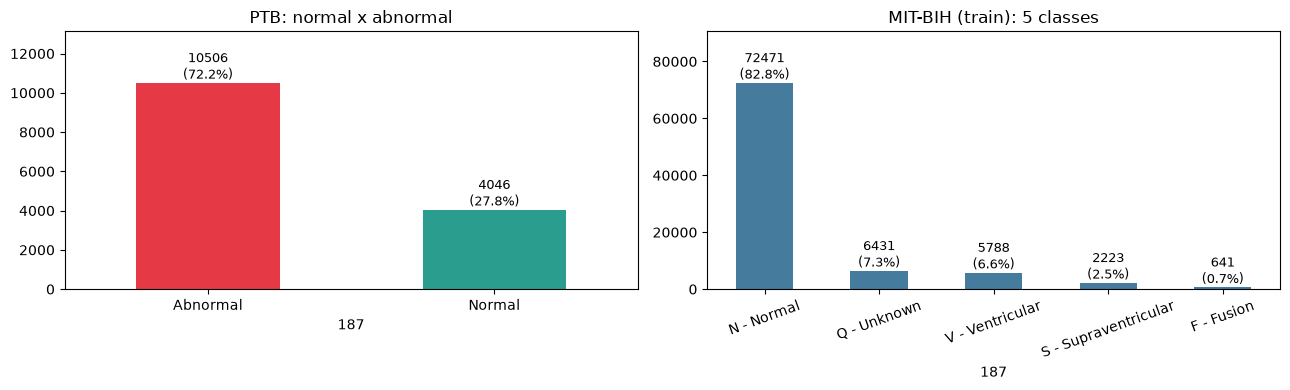

In [3]:
ptb = pd.concat([ptb_normal, ptb_abnormal], ignore_index=True)

for name, df in [("PTB", ptb), ("MIT-BIH train", mit_train), ("MIT-BIH test", mit_test)]:
    signal = df.iloc[:, :-1]
    print(f"{name:<14} | NaN: {df.isna().sum().sum()} | min: {signal.values.min():.3f} | max: {signal.values.max():.3f}"
          f" | duplicated rows: {df.duplicated().sum()}")

dist_ptb = ptb[187].map(dict(enumerate(PTB_NAMES))).value_counts()
dist_mit = mit_train[187].astype(int).map(dict(enumerate(MIT_NAMES))).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
dist_ptb.plot.bar(ax=axes[0], color=["#e63946", "#2a9d8f"], rot=0, title="PTB: normal x abnormal")
dist_mit.plot.bar(ax=axes[1], color="#457b9d", rot=20, title="MIT-BIH (train): 5 classes")
for ax, dist in zip(axes, [dist_ptb, dist_mit]):
    for i, v in enumerate(dist.values):
        ax.annotate(f"{v}\n({v / dist.sum():.1%})", (i, v), ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, dist.max() * 1.25)
plt.tight_layout()
plt.show()

Both datasets are imbalanced (MIT-BIH heavily, ~83% class N), so we also look at per-class recall and macro F1.

### 3.2 Heartbeats per class

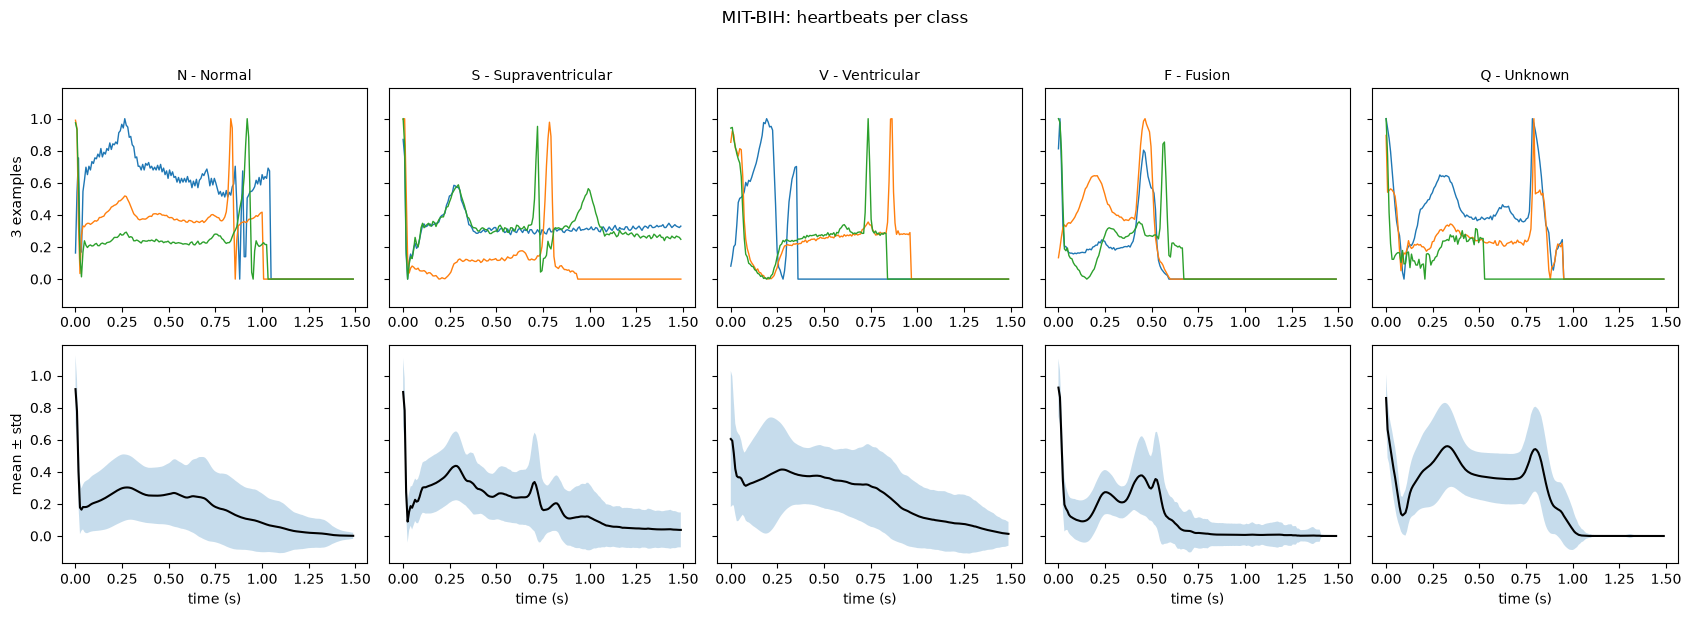

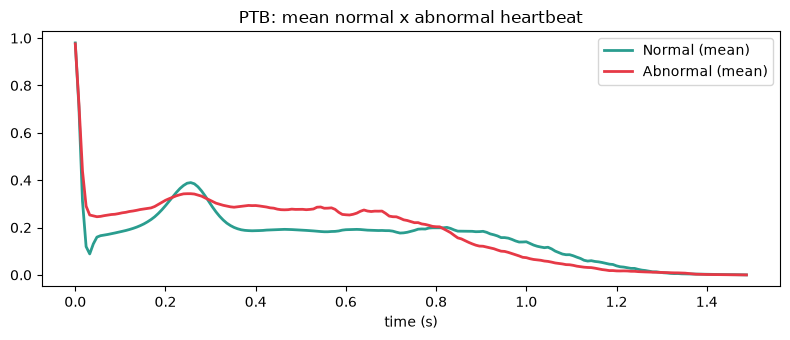

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(17, 6), sharey=True)
for cls, name in enumerate(MIT_NAMES):
    examples = mit_train[mit_train[187] == cls].iloc[:, :-1]
    for _, row in examples.sample(3, random_state=SEED).iterrows():
        axes[0, cls].plot(TIME, row.values, lw=1)
    mean, std = examples.mean().values, examples.std().values
    axes[1, cls].plot(TIME, mean, color="black", lw=1.5)
    axes[1, cls].fill_between(TIME, mean - std, mean + std, alpha=0.25)
    axes[0, cls].set_title(name, fontsize=10)
axes[0, 0].set_ylabel("3 examples")
axes[1, 0].set_ylabel("mean ± std")
for ax in axes[1]:
    ax.set_xlabel("time (s)")
fig.suptitle("MIT-BIH: heartbeats per class", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ecg_mitbih_examples.png", dpi=110, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5))
for cls, color in [(0, "#2a9d8f"), (1, "#e63946")]:
    mean = ptb[ptb[187] == cls].iloc[:, :-1].mean().values
    ax.plot(TIME, mean, color=color, lw=2, label=f"{PTB_NAMES[cls]} (mean)")
ax.set_xlabel("time (s)")
ax.set_title("PTB: mean normal x abnormal heartbeat")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Cleaning

In [5]:
def split_xy(df):
    df = df.drop_duplicates()
    return df.iloc[:, :-1].values.astype("float32"), df.iloc[:, -1].values.astype(int)

X_ptb, y_ptb = split_xy(ptb)
X_mit_train_full, y_mit_train_full = split_xy(mit_train)
X_mit_test, y_mit_test = split_xy(mit_test)
print("PTB:", X_ptb.shape, "| MIT train:", X_mit_train_full.shape, "| MIT test:", X_mit_test.shape)

PTB: (14545, 187) | MIT train: (87554, 187) | MIT test: (21892, 187)


## 5. Model definition and helper functions

`Input(187) → Dense(128, ReLU) → Dense(64, ReLU) → Dropout(0.3) → Dense(32, ReLU) → output`, trained with Adam and EarlyStopping.

In [6]:
def build_mlp(n_classes):
    binary = n_classes == 2
    model = keras.Sequential([
        keras.Input(shape=(N_SAMPLES,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dense(1 if binary else n_classes, activation="sigmoid" if binary else "softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy" if binary else "sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train(model, X_tr, y_tr, X_val, y_val, class_weight=None, epochs=60, batch_size=128):
    early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
    return model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size,
                     class_weight=class_weight, callbacks=[early_stop], verbose=0)


def plot_history(hist, title, filename):
    h = pd.DataFrame(hist.history)
    best = h["val_loss"].idxmin()
    epochs = h.index + 1
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    for ax, metric in zip(axes, ["loss", "accuracy"]):
        ax.plot(epochs, h[metric], label="train")
        ax.plot(epochs, h[f"val_{metric}"], label="validation")
        ax.axvline(best + 1, color="gray", ls="--", lw=1, label=f"best epoch ({best + 1})")
        ax.set_title(f"{title} - {metric}")
        ax.set_xlabel("epoch")
        ax.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / filename, dpi=110, bbox_inches="tight")
    plt.show()
    print(f"Epochs run: {len(h)} | best epoch: {best + 1}")
    print(f"Best epoch -> train loss: {h.loc[best, 'loss']:.4f} | validation loss: {h.loc[best, 'val_loss']:.4f}"
          f" | train acc: {h.loc[best, 'accuracy']:.4f} | validation acc: {h.loc[best, 'val_accuracy']:.4f}")


def plot_confusion(y_true, y_pred, names, title, filename, normalize=False):
    cm = confusion_matrix(y_true, y_pred, normalize="true" if normalize else None)
    fig, ax = plt.subplots(figsize=(5.5 + len(names) * 0.4, 4.5 + len(names) * 0.3))
    ConfusionMatrixDisplay(cm, display_labels=names).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format=".2f" if normalize else "d", xticks_rotation=30)
    ax.set(title=title, xlabel="predicted class", ylabel="actual class")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / filename, dpi=110, bbox_inches="tight")
    plt.show()

## 6. Model A — PTB (normal × abnormal)

### 6.1 Split (70/15/15) and normalization

In [7]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_ptb, y_ptb, test_size=0.30, random_state=SEED, stratify=y_ptb)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

scaler_ptb = StandardScaler().fit(X_tr)
X_tr_s, X_val_s, X_te_s = (scaler_ptb.transform(x) for x in (X_tr, X_val, X_te))

weights_ptb = {i: float(w) for i, w in enumerate(compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr))}
print(f"Train: {len(y_tr)} | Validation: {len(y_val)} | Test: {len(y_te)}")
print("Class weights:", {PTB_NAMES[k]: round(v, 3) for k, v in weights_ptb.items()})

Train: 10181 | Validation: 2182 | Test: 2182
Class weights: {'Normal': 1.798, 'Abnormal': 0.693}


### 6.2 Training

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        24,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,433 (134.50 KB)

 Trainable params: 34,433 (134.50 KB)

 Non-trainable params: 0 (0.00 B)

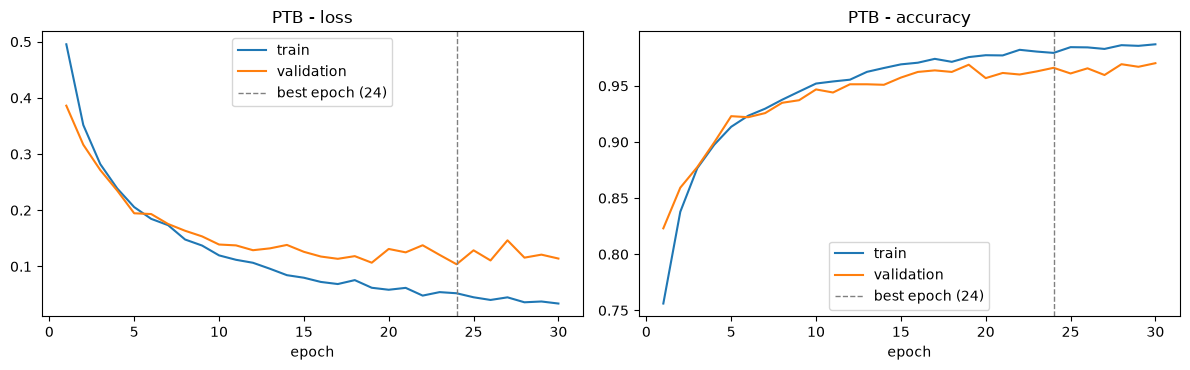

Epochs run: 30 | best epoch: 24
Best epoch -> train loss: 0.0523 | validation loss: 0.1038 | train acc: 0.9794 | validation acc: 0.9661


In [8]:
mlp_ptb = build_mlp(n_classes=2)
mlp_ptb.summary()
hist_ptb = train(mlp_ptb, X_tr_s, y_tr, X_val_s, y_val, class_weight=weights_ptb)
plot_history(hist_ptb, "PTB", "ecg_ptb_training.png")

### 6.3 Evaluation

accuracy                0.9615
precision (abnormal)    0.9757
recall (abnormal)       0.9708
f1 (abnormal)           0.9733 

              precision    recall  f1-score   support

      Normal     0.9252    0.9374    0.9313       607
    Abnormal     0.9757    0.9708    0.9733      1575

    accuracy                         0.9615      2182
   macro avg     0.9505    0.9541    0.9523      2182
weighted avg     0.9617    0.9615    0.9616      2182



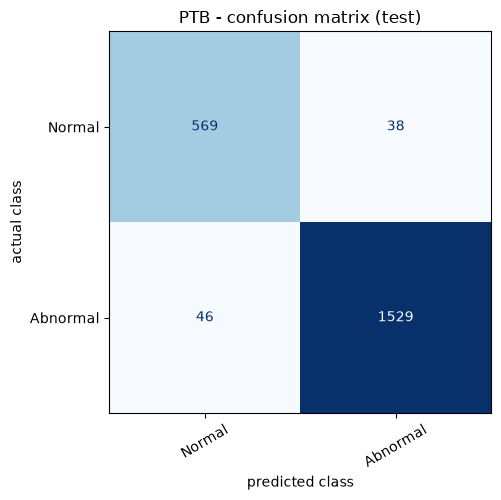

In [9]:
proba_ptb = mlp_ptb.predict(X_te_s, verbose=0).ravel()
pred_ptb = (proba_ptb >= 0.5).astype(int)

metrics_ptb = {
    "accuracy": accuracy_score(y_te, pred_ptb),
    "precision (abnormal)": precision_score(y_te, pred_ptb),
    "recall (abnormal)": recall_score(y_te, pred_ptb),
    "f1 (abnormal)": f1_score(y_te, pred_ptb),
}
print(pd.Series(metrics_ptb).round(4).to_string(), "\n")
print(classification_report(y_te, pred_ptb, target_names=PTB_NAMES, digits=4))
plot_confusion(y_te, pred_ptb, PTB_NAMES, "PTB - confusion matrix (test)", "ecg_ptb_confusion_matrix.png")

## 7. Model B — MIT-BIH (5 heartbeat types)

### 7.1 Split (official test set + 10% validation) and normalization

In [10]:
X_mtr, X_mval, y_mtr, y_mval = train_test_split(
    X_mit_train_full, y_mit_train_full, test_size=0.10, random_state=SEED, stratify=y_mit_train_full)

scaler_mit = StandardScaler().fit(X_mtr)
X_mtr_s, X_mval_s, X_mte_s = (scaler_mit.transform(x) for x in (X_mtr, X_mval, X_mit_test))

balanced = compute_class_weight("balanced", classes=np.unique(y_mtr), y=y_mtr)
weights_mit = {i: float(np.sqrt(w)) for i, w in enumerate(balanced)}
print(f"Train: {len(y_mtr)} | Validation: {len(y_mval)} | Test: {len(y_mit_test)}")
print("Class weights:", {MIT_NAMES[k]: round(v, 2) for k, v in weights_mit.items()})

Train: 78798 | Validation: 8756 | Test: 21892
Class weights: {'N - Normal': 0.49, 'S - Supraventricular': 2.81, 'V - Ventricular': 1.74, 'F - Fusion': 5.23, 'Q - Unknown': 1.65}


### 7.2 Training

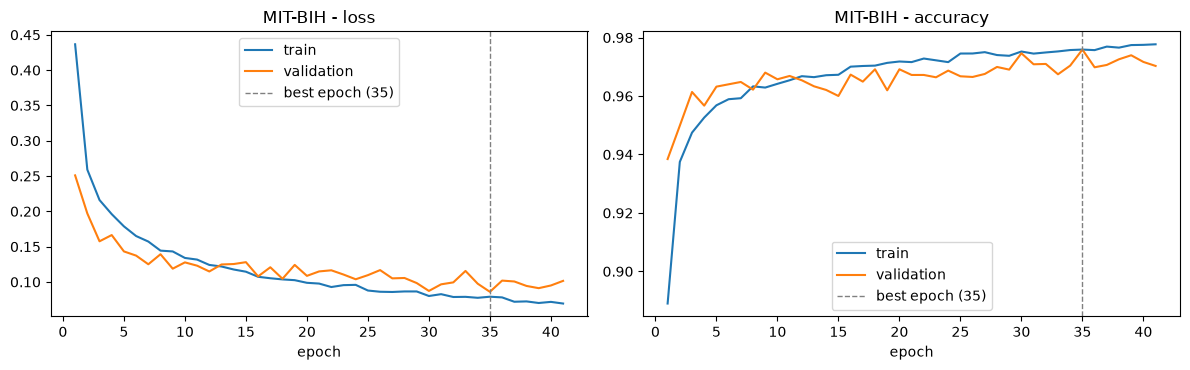

Epochs run: 41 | best epoch: 35
Best epoch -> train loss: 0.0791 | validation loss: 0.0860 | train acc: 0.9759 | validation acc: 0.9759


In [11]:
mlp_mit = build_mlp(n_classes=5)
hist_mit = train(mlp_mit, X_mtr_s, y_mtr, X_mval_s, y_mval, class_weight=weights_mit, batch_size=256)
plot_history(hist_mit, "MIT-BIH", "ecg_mitbih_training.png")

### 7.3 Evaluation

accuracy             0.9728
precision (macro)    0.8442
recall (macro)       0.8935
f1 (macro)           0.8650 

                      precision    recall  f1-score   support

          N - Normal     0.9879    0.9839    0.9859     18118
S - Supraventricular     0.7304    0.7554    0.7427       556
     V - Ventricular     0.9255    0.9351    0.9303      1448
          F - Fusion     0.5911    0.8210    0.6873       162
         Q - Unknown     0.9861    0.9720    0.9790      1608

            accuracy                         0.9728     21892
           macro avg     0.8442    0.8935    0.8650     21892
        weighted avg     0.9742    0.9728    0.9733     21892



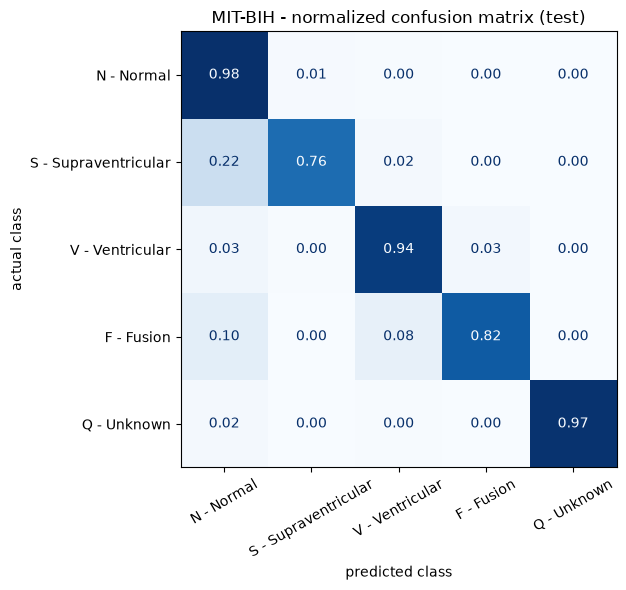

In [12]:
proba_mit = mlp_mit.predict(X_mte_s, verbose=0)
pred_mit = proba_mit.argmax(axis=1)

metrics_mit = {
    "accuracy": accuracy_score(y_mit_test, pred_mit),
    "precision (macro)": precision_score(y_mit_test, pred_mit, average="macro"),
    "recall (macro)": recall_score(y_mit_test, pred_mit, average="macro"),
    "f1 (macro)": f1_score(y_mit_test, pred_mit, average="macro"),
}
print(pd.Series(metrics_mit).round(4).to_string(), "\n")
print(classification_report(y_mit_test, pred_mit, target_names=MIT_NAMES, digits=4))
plot_confusion(y_mit_test, pred_mit, MIT_NAMES, "MIT-BIH - normalized confusion matrix (test)",
               "ecg_mitbih_confusion_matrix.png", normalize=True)

## 8. Prediction examples

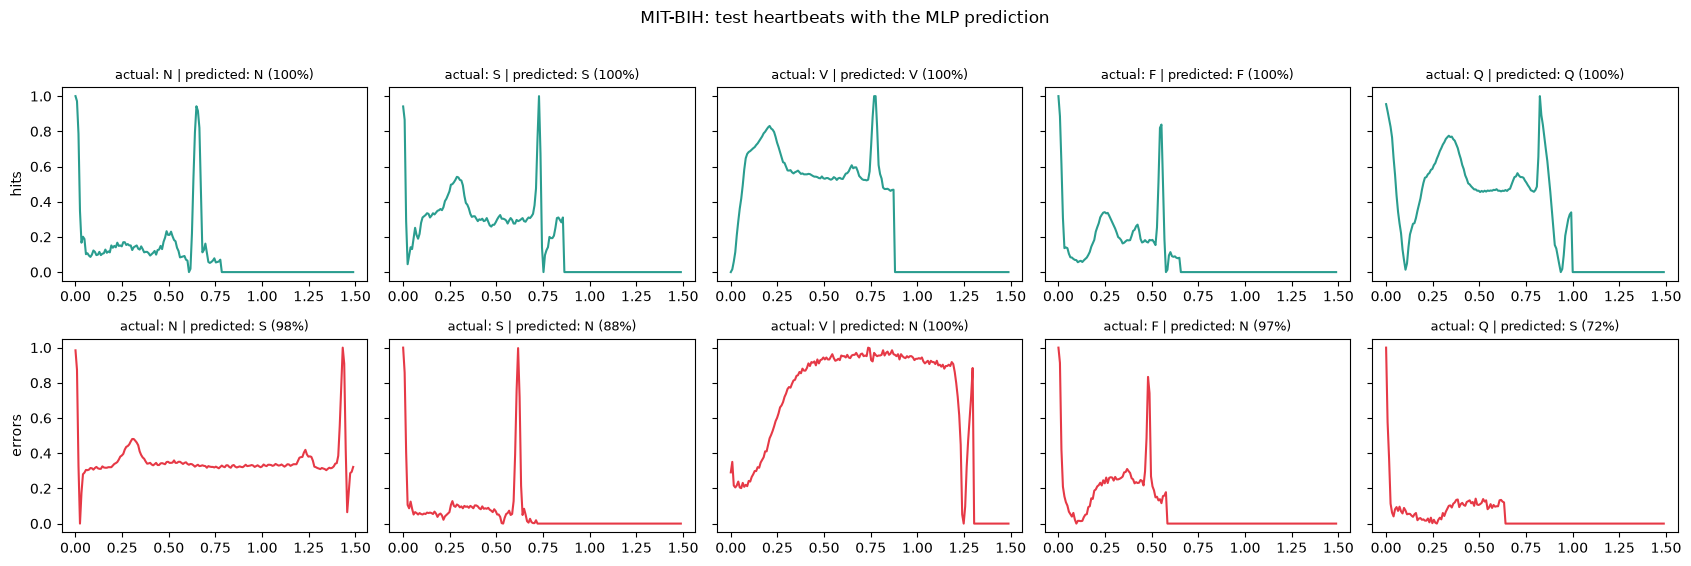

In [13]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(2, 5, figsize=(17, 5.5), sharey=True)
for cls in range(5):
    idx_cls = np.where(y_mit_test == cls)[0]
    hits = idx_cls[pred_mit[idx_cls] == cls]
    errors = idx_cls[pred_mit[idx_cls] != cls]
    for line, group, kind in [(0, hits, "hit"), (1, errors, "error")]:
        ax = axes[line, cls]
        if len(group) == 0:
            ax.set_title(f"{MIT_NAMES[cls][:1]}: no {kind}s", fontsize=9)
            continue
        i = rng.choice(group)
        ax.plot(TIME, X_mit_test[i], color="#2a9d8f" if line == 0 else "#e63946")
        ax.set_title(f"actual: {MIT_NAMES[y_mit_test[i]][:1]} | predicted: {MIT_NAMES[pred_mit[i]][:1]}"
                     f" ({proba_mit[i].max():.0%})", fontsize=9)
axes[0, 0].set_ylabel("hits")
axes[1, 0].set_ylabel("errors")
fig.suptitle("MIT-BIH: test heartbeats with the MLP prediction", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ecg_prediction_examples.png", dpi=110, bbox_inches="tight")
plt.show()

## 9. Saving the results

In [14]:
def history_summary(hist):
    h = pd.DataFrame(hist.history)
    m = int(h["val_loss"].idxmin())
    return {"epochs_run": len(h), "best_epoch": m + 1,
            "train_loss": round(float(h.loc[m, "loss"]), 4), "validation_loss": round(float(h.loc[m, "val_loss"]), 4)}

results = {
    "tensorflow": tf.__version__,
    "ptbdb_binary": {**{k: round(float(v), 4) for k, v in metrics_ptb.items()}, **history_summary(hist_ptb),
                     "n_test": int(len(y_te))},
    "mitbih_multiclass": {**{k: round(float(v), 4) for k, v in metrics_mit.items()}, **history_summary(hist_mit),
                          "n_test": int(len(y_mit_test)),
                          "recall_per_class": dict(zip(MIT_NAMES, recall_score(y_mit_test, pred_mit, average=None).round(4).tolist()))},
}
(RESULTS_DIR / "ecg_metrics.json").write_text(json.dumps(results, indent=2), encoding="utf-8")
print(json.dumps(results, indent=2))

{
  "tensorflow": "2.21.0",
  "ptbdb_binary": {
    "accuracy": 0.9615,
    "precision (abnormal)": 0.9757,
    "recall (abnormal)": 0.9708,
    "f1 (abnormal)": 0.9733,
    "epochs_run": 30,
    "best_epoch": 24,
    "train_loss": 0.0523,
    "validation_loss": 0.1038,
    "n_test": 2182
  },
  "mitbih_multiclass": {
    "accuracy": 0.9728,
    "precision (macro)": 0.8442,
    "recall (macro)": 0.8935,
    "f1 (macro)": 0.865,
    "epochs_run": 41,
    "best_epoch": 35,
    "train_loss": 0.0791,
    "validation_loss": 0.086,
    "n_test": 21892,
    "recall_per_class": {
      "N - Normal": 0.9839,
      "S - Supraventricular": 0.7554,
      "V - Ventricular": 0.9351,
      "F - Fusion": 0.821,
      "Q - Unknown": 0.972
    }
  }
}


## 10. Overfitting check

In [15]:
def train_accuracy(model, X, y, binary):
    p = model.predict(X, verbose=0)
    return accuracy_score(y, (p.ravel() >= 0.5).astype(int) if binary else p.argmax(axis=1))

pd.DataFrame({
    "PTB (binary)": {**history_summary(hist_ptb), "train acc": train_accuracy(mlp_ptb, X_tr_s, y_tr, True),
                     "test acc": metrics_ptb["accuracy"]},
    "MIT-BIH (5 classes)": {**history_summary(hist_mit), "train acc": train_accuracy(mlp_mit, X_mtr_s, y_mtr, False),
                            "test acc": metrics_mit["accuracy"]},
}).T.assign(**{"val/train loss ratio": lambda d: (d["validation_loss"] / d["train_loss"]).round(2)}).round(4)

,epochs_run,best_epoch,train_loss,validation_loss,train acc,test acc,val/train loss ratio
PTB (binary),30.0,24.0,0.0523,0.1038,0.992,0.9615,1.98
MIT-BIH (5 classes),41.0,35.0,0.0791,0.0860,0.985,0.9728,1.09


PTB shows mild overfitting (train accuracy above test accuracy); on MIT-BIH, train and test stay close.

## 11. Limitations

- Data split **by heartbeat, not by patient**: results are optimistic.
- Few source patients (47 in MIT-BIH, 290 in PTB) and little demographic diversity.
- Heartbeats come already segmented and normalized; real ECG is raw and noisy.
- The MLP does not model the temporal order of the signal.
- High accuracy on MIT-BIH is driven by class N; rare classes (S, F) are harder.
- Academic results only — **not a clinical validation**.